In [1]:
# Standard Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split

# Global variables
import warnings
warnings.filterwarnings("ignore")

start_year = 1993

In [2]:
# Custom API
from sys import path

path.append('../API')
from get_curr_year import curr_year

path.append('../API/eda')
from data_visualizations import get_yearly_base_rates, get_seed_pairs, format_plot

path.append('../API/fetch')
import data_fetch as fetch

path.append('../API/model')
from model_selection import get_cv_models
from model_evaluation import evaluate_cv_models, model_predictions, get_classification_report

path.append('../API/preprocess')
from feature_engineering import create_bracket_winners
from data_integrity import season_team_to_coach_team_dict, curr_season_to_tourney_dict
from data_clean import clean_basic_stats, clean_tourney_data
from data_pipeline import dataset_pipeline, feature_pipeline, bracket_pipeline

# Data Fetching

## Examples

### Team Regular Season Stats

In [3]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
basic_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,FT,FTA,FT%,ORB,TRB,AST,STL,BLK,TOV,PF
0,1,Abilene Christian,34,16,18,.471,-4.12,-1.12,NaN,10,...,550,757,.727,329,1139,431,262,72,434,665
1,2,Air Force,31,9,22,.290,-4.77,1.43,NaN,2,...,324,475,.682,225,872,451,202,122,372,541
2,3,Akron NCAA,35,24,11,.686,2.77,-2.08,NaN,13,...,467,642,.727,363,1278,455,197,100,394,583
3,4,Alabama NCAA,37,25,12,.676,20.69,11.80,NaN,13,...,650,842,.772,472,1467,587,256,162,438,734
4,5,Alabama A&M,35,12,23,.343,-14.35,-7.52,NaN,9,...,654,906,.722,394,1248,369,261,136,565,727


In [4]:
adv_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-advanced-school-stats.html", 
                                   attrs={'id': 'adv_school_stats'})
adv_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,3PAr,TS%,TRB%,AST%,STL%,BLK%,eFG%,TOV%,ORB%,FT/FGA
0,1,Abilene Christian,34,16,18,.471,-4.12,-1.12,NaN,10,...,.267,.522,47.7,50.1,10.7,5.5,.479,15.6,26.6,.277
1,2,Air Force,31,9,22,.290,-4.77,1.43,NaN,2,...,.472,.560,46.2,62.0,10.2,11.8,.538,16.9,23.8,.202
2,3,Akron NCAA,35,24,11,.686,2.77,-2.08,NaN,13,...,.428,.555,53.0,49.7,8.4,8.0,.523,14.5,30.6,.231
3,4,Alabama NCAA,37,25,12,.676,20.69,11.80,NaN,13,...,.465,.599,52.6,51.7,9.3,11.0,.563,13.6,35.0,.273
4,5,Alabama A&M,35,12,23,.343,-14.35,-7.52,NaN,9,...,.269,.514,49.8,45.8,10.4,10.7,.459,19.4,31.9,.341


### Coach & Team Performance

In [5]:
coaches_rankings_df = fetch.get_coach_rankings_data(curr_year)
coaches_rankings_df.head()

,Coach_Team,Conf,Top_25,MM,S16,F4,Champs
376,Abilene Christian,WAC,0,,,,
340,Air Force,MWC,0,1,,,
136,Akron,MAC,0,5,1,,
280,Alabama,SEC,1,7,3,1,
164,Alabama A&M,SWAC,0,,,,


### Tournament Game Data

In [6]:
hist_bracket_df = fetch.get_hist_bracket(curr_year)
hist_bracket_df.head()

,Year,Round,Seed,Team,Score,Seed.1,Team.1,Score.1
0,2024,Play-In,16,Wagner,71,16,Howard,68
1,2024,Play-In,10,Colorado,60,10,Boise State,53
2,2024,Play-In,10,Colorado State,67,10,Virginia,42
3,2024,Play-In,16,Grambling,88,16,Montana State,81
4,2024,First Round,1,UConn,91,16,Stetson,52


# Data Pipeline

In [7]:
# Check if the historical data CSV exists, if it doesn't then create it
try:
    mm_matchups_df = pd.read_csv(f'{curr_year}_march_madness_hist_data.csv')
except FileNotFoundError:
    mm_matchups_df = dataset_pipeline(np.arange(start_year, curr_year))
    mm_matchups_df.to_csv(f'{curr_year}_march_madness_hist_data.csv', index=False)

mm_matchups_df

,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,G_Favorite,W_Favorite,W-L%_Favorite,...,eFG%_Underdog,TOV%_Underdog,ORB%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,1993,First Round,1,UNC,16,East Carolina,0,38,34,0.895,...,0.465,17.3,NaN,0.248,CAA,0,1,0,0,0
1,1993,First Round,8,Rhode Island,9,Purdue,0,30,19,0.633,...,0.519,18.8,NaN,0.278,Big Ten,1,10,1,0,0
2,1993,First Round,5,St. John's (NY),12,Texas Tech,0,30,19,0.633,...,0.530,18.1,NaN,0.304,SWC,0,1,0,0,0
3,1993,First Round,4,Arkansas,13,Holy Cross,0,31,22,0.710,...,0.516,16.8,NaN,0.336,Patriot,0,3,0,0,0
4,1993,First Round,6,Virginia,11,Manhattan,0,31,21,0.677,...,0.511,19.8,NaN,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,2023,Sweet Sixteen,2,UCLA,3,Gonzaga,1,37,31,0.838,...,0.582,13.0,31.4,0.233,WCC,1,23,12,2,0
1938,2023,Elite Eight,3,Gonzaga,4,UConn,1,37,31,0.838,...,0.539,15.8,38.4,0.234,Big East,1,5,1,1,1
1939,2023,Final Four,5,San Diego State,9,Florida Atlantic,0,39,32,0.821,...,0.547,14.8,31.6,0.212,CUSA,1,1,1,1,0
1940,2023,Final Four,4,UConn,5,Miami (FL),0,39,31,0.795,...,0.543,14.0,31.8,0.241,ACC,1,11,5,2,0


## Handling Missing Values

### Finding the Nulls

In [8]:
# Given that a feature has any nulls, find the number of nulls present
true_nulls = fetch.get_feature_null_counts(mm_matchups_df)
true_nulls

ORB%_Favorite    765
ORtg_Favorite    765
Pace_Favorite    765
STL%_Favorite    765
Pace_Underdog    764
STL%_Underdog    764
ORtg_Underdog    764
ORB%_Underdog    763
ORB_Underdog     255
ORB_Favorite     254
TOV%_Underdog      3
TOV_Underdog       3
TOV_Favorite       1
TOV%_Favorite      1
dtype: int64

In [9]:
# Get turnover features from true_nulls
tov_null_fills = [col for col in true_nulls.index if ('TOV' in col)]

# All other features found in true_nulls are dropped from our original dataset
null_drops = list(set(true_nulls.index) - set(tov_null_fills))
mm_matchups_df.drop(null_drops, axis=1, inplace=True)

In [10]:
# View the rows containing all of the dataset's nulls to be imputed
# This will be a useful reference to validate the proper imputation of the nulls
tov_nulls_rows = fetch.get_null_rows(tov_null_fills, mm_matchups_df)
display(tov_nulls_rows)

,Year,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite,Underdog_Upset
47,1993,NaN,NaN,373.0,15.9,1
54,1993,16.6,552.0,NaN,NaN,0
57,1993,NaN,NaN,561.0,17.4,0
470,2000,NaN,NaN,520.0,17.8,0


### What are the Distributions of the Features We Wish to Impute?

1993 feature distributions
2000 feature distributions


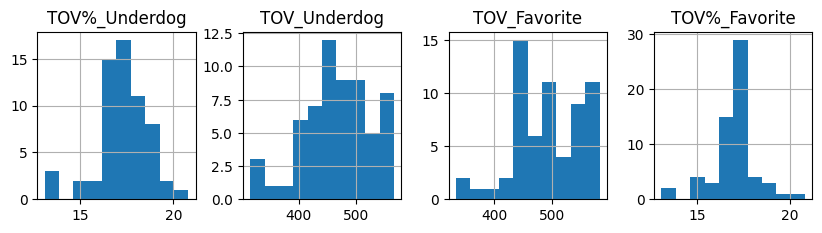

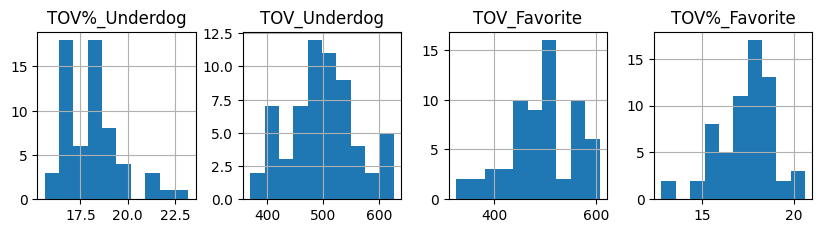

In [11]:
# View the distributions of the dataset's turnover features
tov_null_years = sorted(list(set(tov_nulls_rows['Year'])))

for year in tov_null_years:
    print(f"{year} feature distributions")
    year_df = mm_matchups_df[mm_matchups_df['Year'] == year]
    year_df[tov_null_fills].hist(figsize=(10, 5), layout=(len(tov_null_years), len(tov_null_fills)))

### Impute TOV Nulls by Season & Target Variable

In [12]:
# Retrieve TOV feature means by season; only include seasons that contain nulls
tov_col_means = mm_matchups_df[tov_nulls_rows.columns].groupby(['Year', 'Underdog_Upset']).mean()
tov_col_means.loc[tov_null_years]

TOV%_Underdog  TOV_Underdog  TOV_Favorite  TOV%_Favorite
Year Underdog_Upset                                                          
1993 0                   17.360000    463.044444    496.666667      16.984444
     1                   17.056250    475.937500    481.941176      17.282353
2000 0                   18.336364    492.704545    507.733333      17.511111
     1                   17.544444    511.000000    468.944444      17.066667

In [13]:
for year in tov_null_years:
    for label in [0, 1]:
        for col in tov_null_fills:
            # Get feature's rows with nulls for given year & label type
            fill_condition = (tov_nulls_rows['Year'] == year) & (tov_nulls_rows['Underdog_Upset'] == label)
            col_fill_rows = tov_nulls_rows[fill_condition].index
            # Get feature's mean for given year
            col_year_mean = np.round(tov_col_means.loc[(year, label), col], 1)
            # Impute nulls of interest
            mm_matchups_df.loc[col_fill_rows, col] = mm_matchups_df.loc[col_fill_rows, col].fillna(col_year_mean)

# Display rows that originally had nulls to see if they match discovered feature means
mm_matchups_df.loc[tov_nulls_rows.index, tov_null_fills]

,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite
47,17.1,475.9,373.0,15.9
54,16.6,552.0,496.7,17.0
57,17.4,463.0,561.0,17.4
470,18.3,492.7,520.0,17.8


# Exploratory Data Analysis (EDA)

## What is our Bracket's Accuracy if We Guess the Favorite Always Wins?

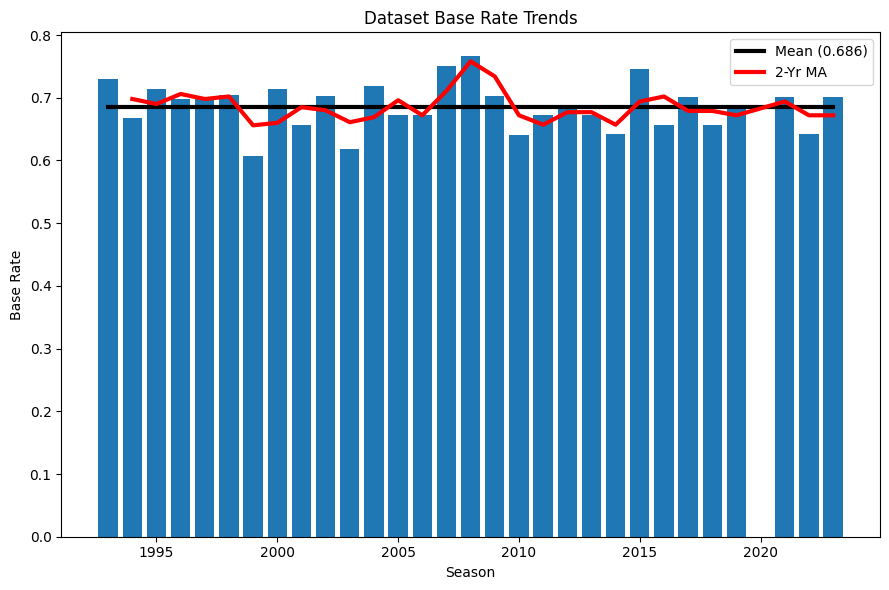

In [14]:
# Each season's base rate
yearly_base_rates = get_yearly_base_rates(mm_matchups_df)
# Dataset's mean base rate
mean_base_rate = np.round(yearly_base_rates.mean(), 3)
# Moving average
years_ma = 2
base_rate_ma = np.round(yearly_base_rates.rolling(years_ma).mean(), 3)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_base_rates.index, [mean_base_rate] * len(yearly_base_rates), color='k', linewidth=3, label=f'Mean ({mean_base_rate})')
plt.plot(yearly_base_rates.index, base_rate_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_base_rates.index, yearly_base_rates)

format_plot(title='Dataset Base Rate Trends', xlabel='Season', ylabel='Base Rate')

## How Often Do Upsets Occur in a Given Year's March Madness?

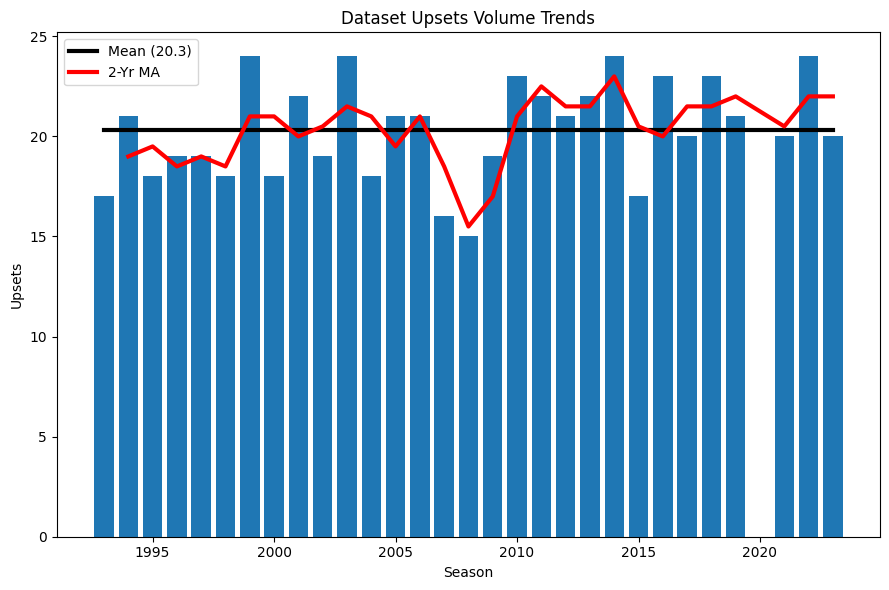

In [15]:
# Each season's upset count
yearly_upsets = mm_matchups_df.groupby('Year').agg({'Underdog_Upset': 'sum'})
# Dataset's mean upset count
mean_upsets = np.round(yearly_upsets['Underdog_Upset'].mean(), 1)
# Moving average
upsets_ma = np.round(yearly_upsets.rolling(years_ma).mean(), 1)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_upsets.index, [mean_upsets] * len(yearly_upsets), color='k', linewidth=3, label=f'Mean ({mean_upsets})')
plt.plot(yearly_upsets.index, upsets_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_upsets.index, yearly_upsets['Underdog_Upset'])

format_plot(title='Dataset Upsets Volume Trends', xlabel='Season', ylabel='Upsets')

## What is the Distribution of Upsets Across the Tournament Rounds?

In [16]:
# Retrieve data about March Madness matchup seed pairings
seed_pairs = get_seed_pairs(mm_matchups_df)
# Extract seed pairs that resulted in upsets
upset_pairs = seed_pairs[seed_pairs['Underdog_Upset'] == 1]

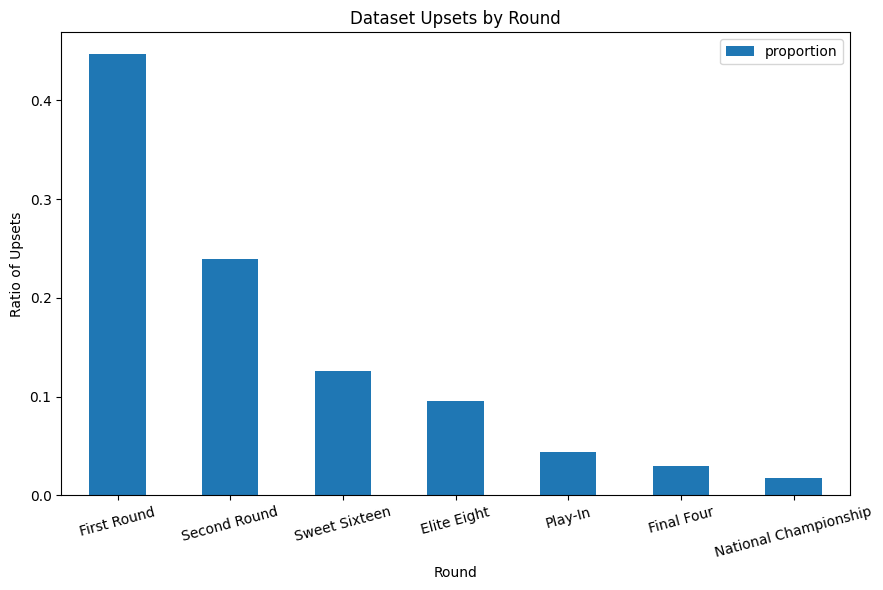

In [17]:
# Group upset seed pairs by round and count them
upset_rounds_freq = upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Dataset Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

## Which Seeding Combinations are the Most Likely to Produce Upsets?

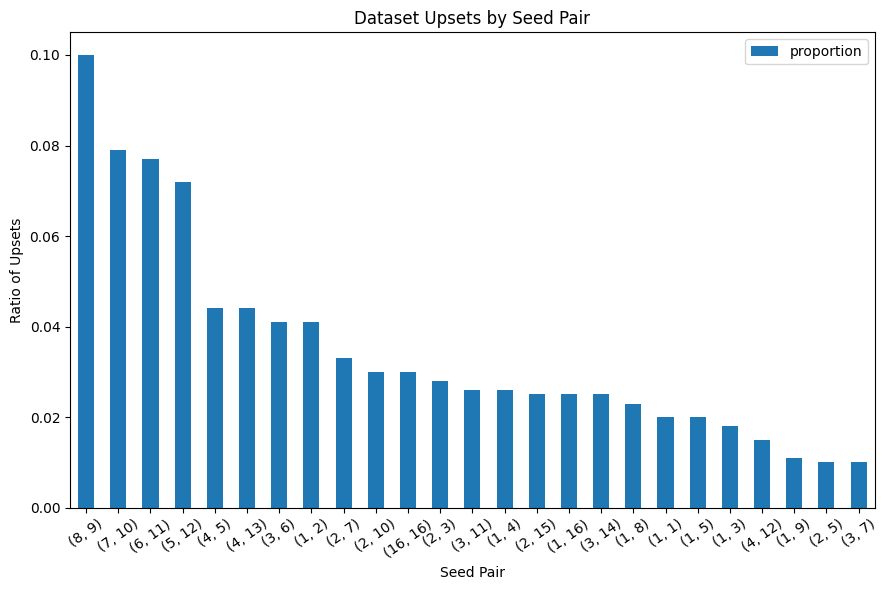

In [18]:
# Group upsets by seed pairing and count them
upset_pairs_freq = np.round(upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Dataset Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

# Feature Engineering & Analysis

In [19]:
# Drop unneeded features
mm_matchups_df.drop(['Year', 'Team_Favorite', 'Team_Underdog'], axis=1, inplace=True)
# Store rounds data (for EDA visualizations)
all_rounds = mm_matchups_df['Round']

# Create feature matrix and target variable
X = mm_matchups_df.drop('Underdog_Upset', axis=1)
y = mm_matchups_df['Underdog_Upset']

display(X), display(y)

,Round,Seed_Favorite,Seed_Underdog,G_Favorite,W_Favorite,W-L%_Favorite,SRS_Favorite,Conf_W_Favorite,Conf_L_Favorite,Home_W_Favorite,...,BLK%_Underdog,eFG%_Underdog,TOV%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,First Round,1,16,38,34,0.895,29.04,14,2,12,...,5.9,0.465,17.3,0.248,CAA,0,1,0,0,0
1,First Round,8,9,30,19,0.633,9.50,8,6,9,...,5.3,0.519,18.8,0.278,Big Ten,1,10,1,0,0
2,First Round,5,12,30,19,0.633,13.14,12,6,12,...,5.6,0.530,18.1,0.304,SWC,0,1,0,0,0
3,First Round,4,13,31,22,0.710,17.72,10,6,12,...,5.9,0.516,16.8,0.336,Patriot,0,3,0,0,0
4,First Round,6,11,31,21,0.677,14.60,9,7,12,...,6.2,0.511,19.8,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,Sweet Sixteen,2,3,37,31,0.838,22.11,18,2,17,...,9.3,0.582,13.0,0.233,WCC,1,23,12,2,0
1938,Elite Eight,3,4,37,31,0.838,18.99,14,2,15,...,12.7,0.539,15.8,0.234,Big East,1,5,1,1,1
1939,Final Four,5,9,39,32,0.821,15.81,15,3,15,...,6.7,0.547,14.8,0.212,CUSA,1,1,1,1,0
1940,Final Four,4,5,39,31,0.795,22.95,13,7,15,...,8.4,0.543,14.0,0.241,ACC,1,11,5,2,0


0       0
1       0
2       0
3       0
4       0
       ..
1937    1
1938    1
1939    0
1940    0
1941    0
Name: Underdog_Upset, Length: 1942, dtype: int64

(None, None)

In [20]:
"""We'll stratify the 80-20 split of our training & test datasets according to the target
variable's distribution so our model can learn the trends observed in our EDA"""
# Drop round data because it's already stored in previous notebook cell
X.drop('Round', axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=pd.concat([y, all_rounds], axis=1))

# All datasets will be scaled based on fit found for training dataset
basic_stats_cols = clean_basic_stats(basic_stats_df).columns
data_cuts = {    
    'FULL': X,
    'TRAIN': X_train,
    'TEST': X_test,
}

# Pass datasets through feature pipeline to prep them for model fitting
prep_X_train = feature_pipeline('TRAIN', data_cuts, basic_stats_cols)
prep_X_test = feature_pipeline('TEST', data_cuts, basic_stats_cols)

prep_all_X = pd.concat([prep_X_train, prep_X_test])
prep_all_X

,Seed_Favorite,Seed_Underdog,Underdog_Rel_TOV/Game,Underdog_Rel_FT%,Underdog_Rel_TS%,Underdog_Rel_SRS,Underdog_Rel_AST/Game,Underdog_Rel_W-L%,Underdog_Rel_FG/Game,Underdog_Rel_Top_25,...,Underdog_Rel_Away_L/Game,Underdog_Rel_Home_L/Game,Underdog_Rel_3P%,Underdog_Rel_S16,Underdog_Rel_Champs,Underdog_Rel_MM,Underdog_Rel_FG%,Underdog_Rel_Home_W/Game,Conf_Favorite,Conf_Underdog
321,1.037565,-0.005557,-0.163595,-0.481055,-0.857632,0.417256,-0.972464,1.000028,-0.447068,1.145780,...,-1.683512,-0.283949,-0.615073,-1.845678,-2.566712,-1.350403,-1.105014,1.396485,9.0,5.0
1635,0.040450,-1.274669,-0.260032,-0.261197,0.546257,1.139970,-0.010377,0.217774,0.085205,1.145780,...,0.549190,-0.283949,0.400452,0.027857,0.362811,0.082169,1.124001,0.330240,28.0,3.0
457,-0.291922,1.009732,0.704337,0.918043,0.217687,-1.326473,-0.451333,0.066370,-0.056735,-0.824759,...,1.665541,1.040294,-0.080586,-0.483107,0.362811,-0.468820,-0.117879,-1.802248,3.0,17.0
1511,0.705193,0.248265,-1.610147,0.038610,-1.036852,0.825905,0.230145,0.714043,-0.659977,-0.824759,...,-0.567161,-0.283949,-1.363355,-0.142465,0.362811,0.853555,-1.296072,-0.736004,26.0,20.0
1836,0.040450,0.502088,-0.886871,-0.081313,0.337167,0.266893,0.871537,-0.774764,0.652962,-0.824759,...,-0.567161,1.040294,-0.240932,0.538821,0.362811,0.192367,0.550826,-1.802248,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,-0.291922,-1.528491,-0.645779,-0.980732,-0.260232,1.753549,0.430580,0.705632,0.794901,1.145780,...,-1.683512,-0.283949,1.202183,2.923319,1.339318,3.277909,-0.245251,-0.736004,7.0,7.0
1279,0.040450,0.755910,-0.211813,1.957372,1.860536,-1.610223,-0.170725,0.907504,-0.092219,-0.824759,...,-0.567161,-0.283949,1.148734,-2.356642,-0.613697,-2.452382,1.155844,1.396485,7.0,8.0
965,0.372821,0.502088,-0.356469,2.197217,0.217687,0.140782,-0.611681,-0.000921,-1.227734,-0.824759,...,0.549190,-0.283949,-0.588349,1.049785,0.362811,0.743357,-0.468153,0.330240,3.0,7.0
916,0.372821,0.502088,-0.260032,1.097927,0.456647,-0.547979,-0.210812,1.185078,0.511023,-0.824759,...,-0.567161,-0.283949,0.427177,0.198178,0.362811,0.192367,0.518983,-0.736004,28.0,11.0


### What are the Distributions of all our Features?

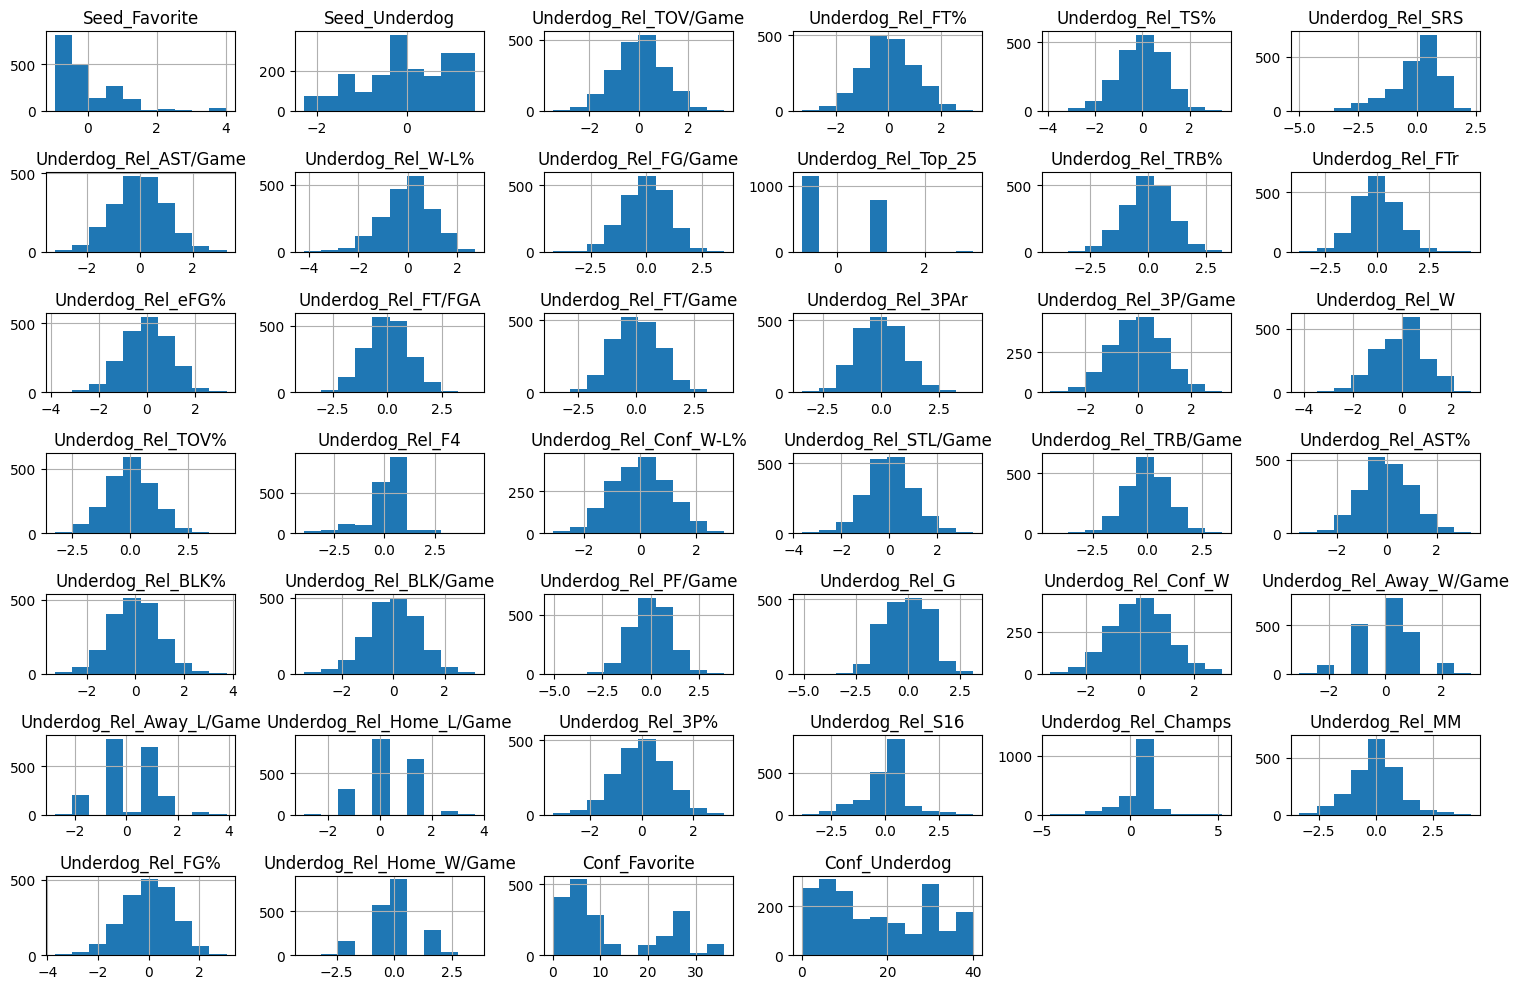

In [21]:
prep_all_X.hist(figsize=(15, 10))
plt.tight_layout()

### What Features have the Greatest Predictive Power?

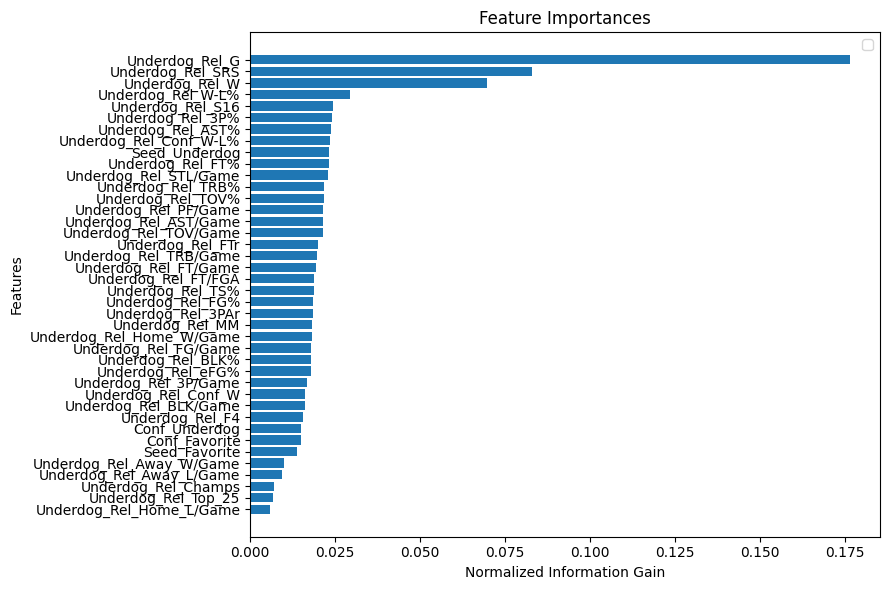

In [22]:
# Fit data to a Random Forest to find feature importances
rf = RandomForestClassifier().fit(prep_X_train, y_train)

# Sort features & their corresponding values in by importance
importances = rf.feature_importances_
feat_importances = prep_all_X.columns[np.argsort(importances)]
feat_values = np.sort(importances)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(feat_importances, feat_values)

format_plot(title='Feature Importances', xlabel='Normalized Information Gain', ylabel='Features')

### What are the Correlations Between Features?

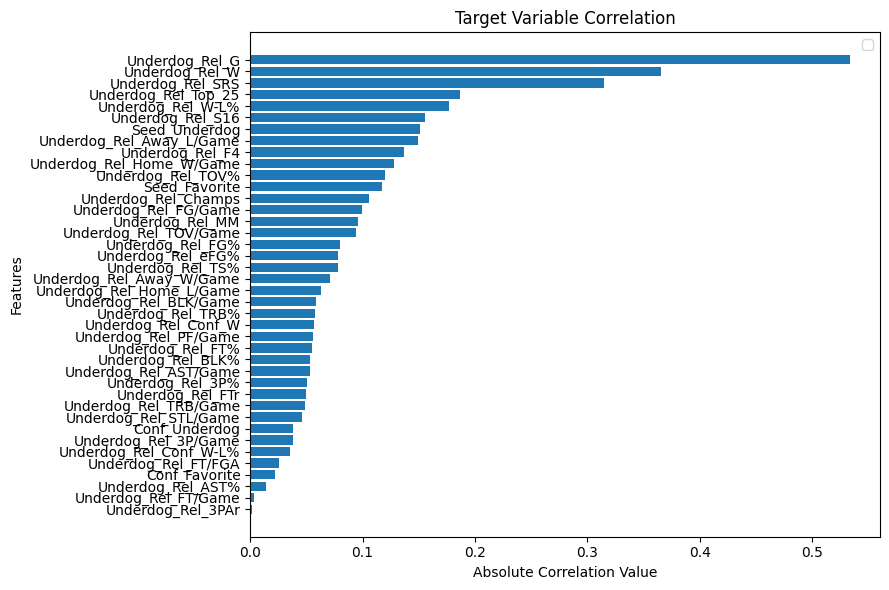

In [23]:
# Get feature matrix's correlations to target variable, then sort by absolute value
prep_X_y = prep_X_train.merge(y_train, left_index=True, right_index=True)
abs_desc_corr = np.abs(prep_X_y.corr().loc['Underdog_Upset']).sort_values()
abs_desc_corr.drop('Underdog_Upset', inplace=True)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(abs_desc_corr.index, abs_desc_corr.values)

format_plot(title='Target Variable Correlation', xlabel='Absolute Correlation Value', ylabel='Features')

# Model Selection

### Cross-Validation

In [24]:
%%time

# Perform CV on chosen models with the training set, then assess their respective performances
cv_models = get_cv_models(y)
model_performance = evaluate_cv_models(cv_models, prep_X_train, y_train)
     
model_performance

CPU times: total: 40.9 s
Wall time: 51.5 s


,Best_Mean_Accuracy,Best_Mean_Accuracy_Std
Naive Bayes,0.733,0.018
LogReg,0.817,0.019
SVM,0.813,0.016
Random Forest,0.818,0.017
XGBoost,0.818,0.029


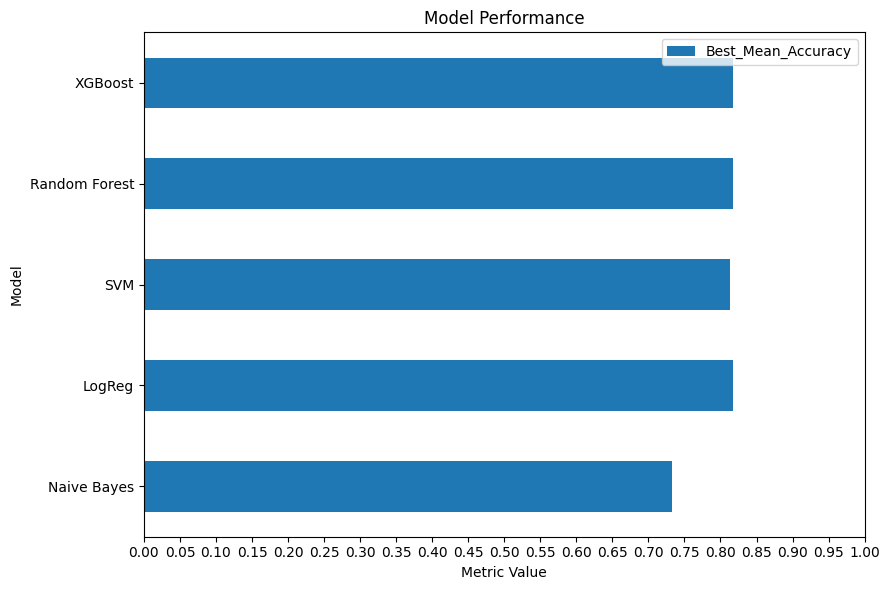

In [25]:
# Plot the performance of each model against the Accuracy metric
model_performance['Best_Mean_Accuracy'].plot(figsize=(9, 6), kind='barh', xticks=np.arange(0, 1.01, 0.05))

format_plot(title='Model Performance', xlabel='Metric Value', ylabel='Model')

In [26]:
# Identify best model to use
selected_model = 'Random Forest'
best_model = cv_models[selected_model][-1].best_estimator_
best_params = cv_models[selected_model][-1].best_params_

display(best_params)

{'random_state': 42,
 'n_estimators': np.int64(150),
 'min_samples_split': 16,
 'min_samples_leaf': 8,
 'criterion': 'entropy'}

# Model Evaluation

In [27]:
# Concatenate all visualization data into a single DataFrame
test_game_data = pd.concat([y_test, all_rounds, mm_matchups_df[['Seed_Favorite', 'Seed_Underdog']]], 
                           join='inner', axis=1).drop('Underdog_Upset', axis=1)

# Overwrite the actual target variable (used for the join) with the best model's predictions
y_preds = model_predictions(best_model, prep_X_test)
test_game_data['Underdog_Upset'] = y_preds

# Get seed pairs data
test_seed_pairs = get_seed_pairs(test_game_data)
# Extract seed pairs that resulted in upsets
test_upset_pairs = test_seed_pairs[test_seed_pairs['Underdog_Upset'] == 1]

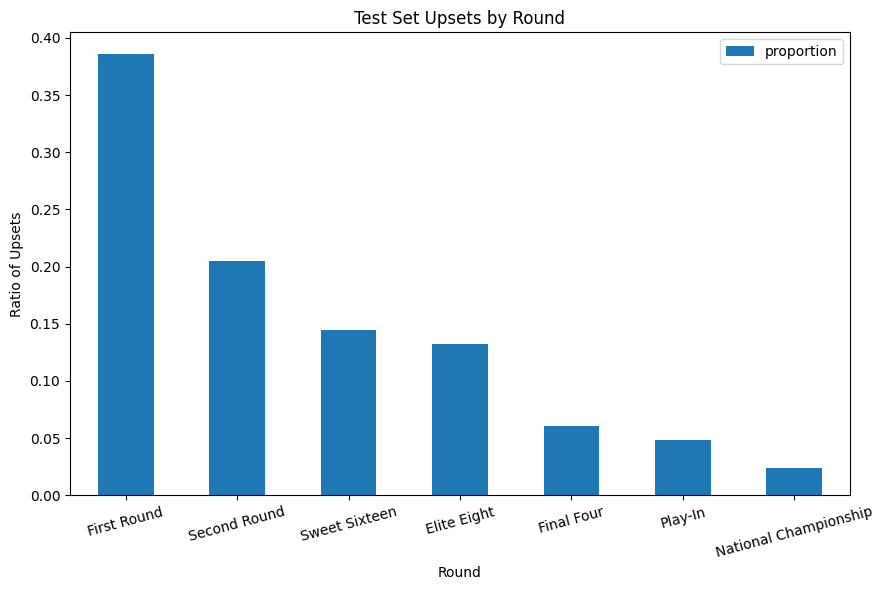

In [28]:
# Group upset seed pairs by round and count them
test_upset_rounds_freq = test_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
test_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Test Set Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

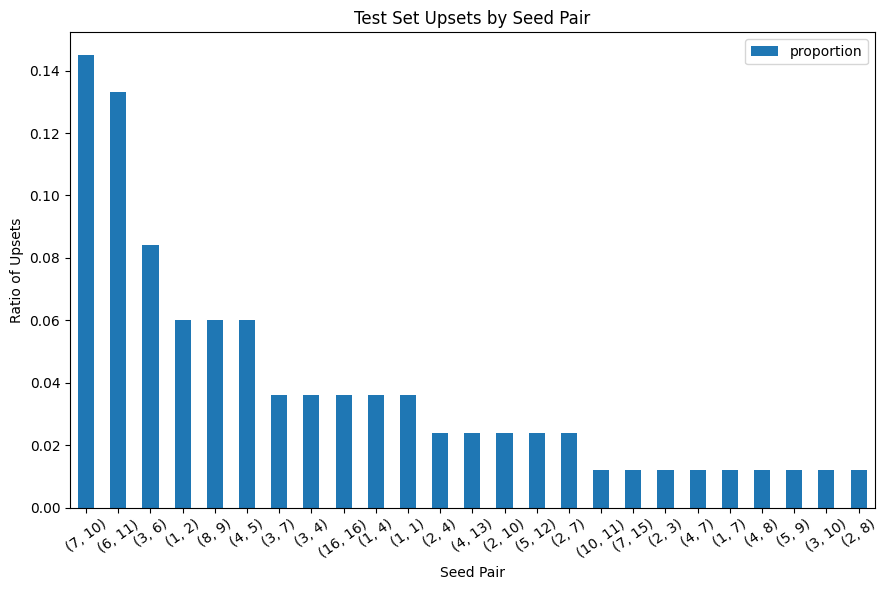

In [29]:
# Group upsets by seed pairing and count them
test_upset_pairs_freq = np.round(test_upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
test_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Test Set Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

In [30]:
# Show confusion matrix for model's test set predictions
test_set_report = get_classification_report(y_test, y_preds)
print("Test Set Metrics Report \n\n", test_set_report)

Test Set Metrics Report 

               precision    recall  f1-score   support

           0       0.82      0.94      0.88       267
           1       0.81      0.55      0.65       122

    accuracy                           0.82       389
   macro avg       0.81      0.74      0.76       389
weighted avg       0.82      0.82      0.81       389



# 2024 March Madness Predictions

## Data Pipeline

In [31]:
# Check if the starting bracket CSV exists, if it doesn't then create it
try:
    curr_bracket_df = pd.read_csv(f'{curr_year}_march_madness_curr_start_bracket.csv')
except FileNotFoundError:
    curr_bracket_df = fetch.get_current_bracket()
    curr_bracket_df.to_csv(f'{curr_year}_march_madness_curr_start_bracket.csv', index=False)

# Extract play-in matchups
play_in = curr_bracket_df[:4]

# Extract first round matchups
first_round = curr_bracket_df[4:]
first_round.index = range(len(first_round))

display(play_in), display(first_round)

,Seed,Team,Seed.1,Team.1
0,16,Grambling,16,Montana State
1,10,Colorado State,10,Virginia
2,10,Colorado,10,Boise State
3,16,Wagner,16,Howard


,Seed,Team,Seed.1,Team.1
0,1,UConn,16,Stetson
1,8,Florida Atlantic,9,Northwestern
2,5,San Diego State,12,UAB
3,4,Auburn,13,Yale
4,6,BYU,11,Duquesne
5,3,Illinois,14,Morehead State
6,7,Washington State,10,Drake
7,2,Iowa State,15,South Dakota State
8,1,Purdue,0,NaN
9,8,Utah State,9,TCU


(None, None)

In [32]:
# Check if bracket predictions have already been generated, otherwise create them
try:
    bracket_preds = pd.read_csv(f'{curr_year}_march_madness_bracket_predictions.csv')
except FileNotFoundError:
    bracket_preds = bracket_pipeline(curr_year, play_in, first_round, best_model, data_cuts, null_drops)
    bracket_preds.to_csv(f'{curr_year}_march_madness_bracket_predictions.csv', index=False)

# Display bracket_pipeline() predictions by round
for _round in bracket_preds['Round'].unique():
    display(bracket_preds[bracket_preds['Round'] == _round])

,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
0,16,Grambling,16,Montana State,Play-In,0,Grambling
1,10,Colorado State,10,Virginia,Play-In,0,Colorado State
2,10,Colorado,10,Boise State,Play-In,0,Colorado
3,16,Wagner,16,Howard,Play-In,1,Howard


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
4,1,UConn,16,Stetson,First Round,0,UConn
5,8,Florida Atlantic,9,Northwestern,First Round,0,Florida Atlantic
6,5,San Diego State,12,UAB,First Round,0,San Diego State
7,4,Auburn,13,Yale,First Round,0,Auburn
8,6,BYU,11,Duquesne,First Round,1,Duquesne
9,3,Illinois,14,Morehead State,First Round,0,Illinois
10,7,Washington State,10,Drake,First Round,0,Washington State
11,2,Iowa State,15,South Dakota State,First Round,0,Iowa State
12,1,Purdue,16,Grambling,First Round,0,Purdue
13,8,Utah State,9,TCU,First Round,0,Utah State


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
36,1,UConn,8,Florida Atlantic,Second Round,0,UConn
37,4,Auburn,5,San Diego State,Second Round,1,San Diego State
38,3,Illinois,11,Duquesne,Second Round,0,Illinois
39,2,Iowa State,7,Washington State,Second Round,0,Iowa State
40,1,Purdue,8,Utah State,Second Round,0,Purdue
41,4,Kansas,5,Gonzaga,Second Round,1,Gonzaga
42,3,Creighton,11,Oregon,Second Round,1,Oregon
43,2,Tennessee,10,Colorado State,Second Round,0,Tennessee
44,1,Houston,9,Texas A&M,Second Round,0,Houston
45,4,Duke,5,Wisconsin,Second Round,0,Duke


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
52,1,UConn,5,San Diego State,Sweet Sixteen,0,UConn
53,2,Iowa State,3,Illinois,Sweet Sixteen,1,Illinois
54,1,Purdue,5,Gonzaga,Sweet Sixteen,0,Purdue
55,2,Tennessee,11,Oregon,Sweet Sixteen,0,Tennessee
56,1,Houston,4,Duke,Sweet Sixteen,0,Houston
57,2,Marquette,11,NC State,Sweet Sixteen,1,NC State
58,1,UNC,4,Alabama,Sweet Sixteen,0,UNC
59,2,Arizona,6,Clemson,Sweet Sixteen,0,Arizona


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
60,1,UConn,3,Illinois,Elite Eight,0,UConn
61,1,Purdue,2,Tennessee,Elite Eight,0,Purdue
62,1,Houston,11,NC State,Elite Eight,0,Houston
63,1,UNC,2,Arizona,Elite Eight,0,UNC


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
64,1,UConn,1,Purdue,Final Four,0,UConn
65,1,Houston,1,UNC,Final Four,0,Houston


,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Round,Underdog_Upset,Winner
66,1,UConn,1,Houston,National Championship,0,UConn


## Pre-Tournament Model Evaluation (3/20/24)

In [33]:
# Get seed pairs data
curr_seed_pairs = get_seed_pairs(bracket_preds)
# Extract seed pairs that resulted in upsets
curr_upset_pairs = curr_seed_pairs[curr_seed_pairs['Underdog_Upset'] == 1]

Total Upsets: 17


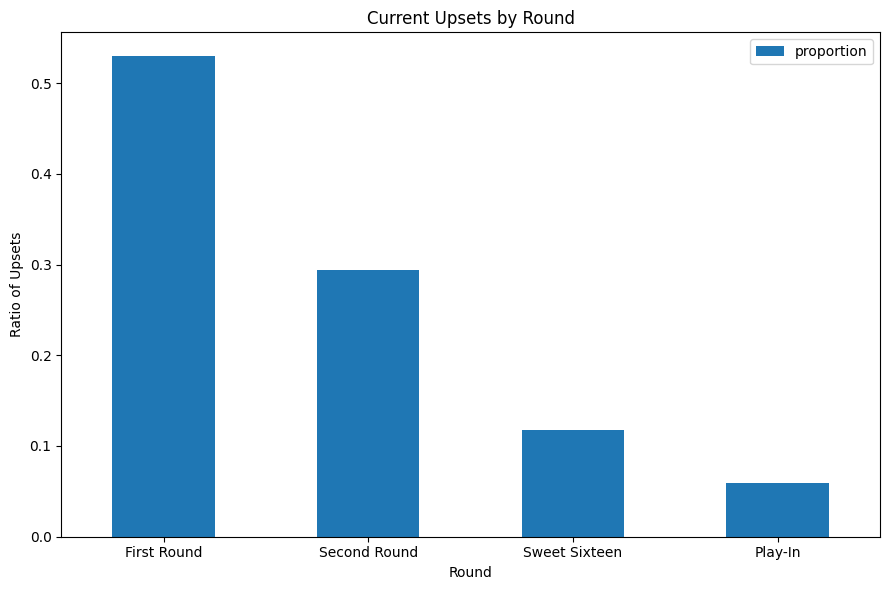

In [34]:
# Group upset seed pairs by round and count them
curr_upset_rounds_freq = curr_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
curr_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='Current Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(curr_upset_pairs)}")

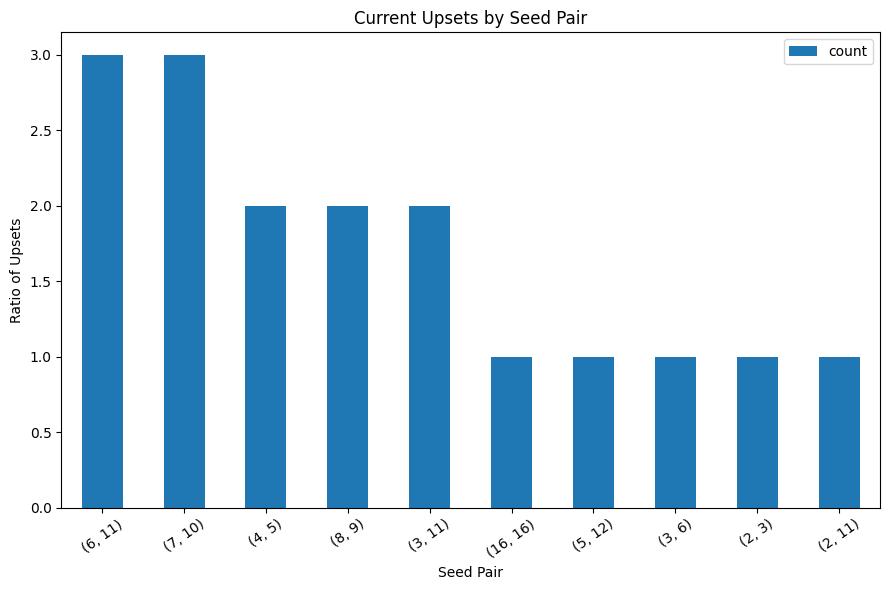

In [35]:
# Group upsets by seed pairing and count them
curr_upset_pairs_freq = curr_upset_pairs['Pairs'].value_counts()

# Plot findings
curr_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Current Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

## Post-Tournament Model Evaluation (2/26/26)

### True Tournament Outcomes EDA

In [36]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/men/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
clean_basic_stats_df = clean_basic_stats(basic_stats_df)

# Clean basic stats' school names to properly merge with raw tournament data
if clean_basic_stats_df['School'].str.contains('NCAA').any():
    clean_basic_stats_df['School'] = clean_basic_stats_df['School'].apply(lambda school: school[:-5])

clean_basic_stats_df['School'].replace(season_team_to_coach_team_dict, inplace=True)

# Create DataFrame (data integrity intact) with all March Madness outcomes
bracket_trues = clean_tourney_data(hist_bracket_df, clean_basic_stats_df)

bracket_trues['Team_Favorite'].replace(curr_season_to_tourney_dict, inplace=True)
bracket_trues['Team_Underdog'].replace(curr_season_to_tourney_dict, inplace=True)

create_bracket_winners(bracket_trues)

# Display true tournament results by round
for _round in bracket_trues['Round'].unique():
    display(bracket_trues[bracket_trues['Round'] == _round])

,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
0,2024,Play-In,16,Wagner,16,Howard,0,Wagner
1,2024,Play-In,10,Colorado,10,Boise State,0,Colorado
2,2024,Play-In,10,Colorado State,10,Virginia,0,Colorado State
3,2024,Play-In,16,Grambling,16,Montana State,0,Grambling


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
4,2024,First Round,1,UConn,16,Stetson,0,UConn
5,2024,First Round,8,Florida Atlantic,9,Northwestern,1,Northwestern
6,2024,First Round,5,San Diego State,12,UAB,0,San Diego State
7,2024,First Round,4,Auburn,13,Yale,1,Yale
8,2024,First Round,6,BYU,11,Duquesne,1,Duquesne
9,2024,First Round,3,Illinois,14,Morehead State,0,Illinois
10,2024,First Round,7,Washington State,10,Drake,0,Washington State
11,2024,First Round,2,Iowa State,15,South Dakota State,0,Iowa State
19,2024,First Round,1,Purdue,16,Grambling,0,Purdue
20,2024,First Round,8,Utah State,9,TCU,0,Utah State


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
12,2024,Second Round,1,UConn,9,Northwestern,0,UConn
13,2024,Second Round,5,San Diego State,13,Yale,0,San Diego State
14,2024,Second Round,3,Illinois,11,Duquesne,0,Illinois
15,2024,Second Round,2,Iowa State,7,Washington State,0,Iowa State
27,2024,Second Round,1,Purdue,8,Utah State,1,Utah State
28,2024,Second Round,4,Kansas,5,Gonzaga,1,Gonzaga
29,2024,Second Round,3,Creighton,11,Oregon,0,Creighton
30,2024,Second Round,2,Tennessee,7,Texas,0,Tennessee
42,2024,Second Round,1,Houston,9,Texas A&M,1,Texas A&M
43,2024,Second Round,4,Duke,12,James Madison,0,Duke


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
16,2024,Sweet Sixteen,1,UConn,5,San Diego State,0,UConn
17,2024,Sweet Sixteen,2,Iowa State,3,Illinois,1,Illinois
31,2024,Sweet Sixteen,1,Purdue,5,Gonzaga,0,Purdue
32,2024,Sweet Sixteen,2,Tennessee,3,Creighton,0,Tennessee
46,2024,Sweet Sixteen,1,Houston,4,Duke,1,Duke
47,2024,Sweet Sixteen,2,Marquette,11,NC State,1,NC State
61,2024,Sweet Sixteen,1,UNC,4,Alabama,1,Alabama
62,2024,Sweet Sixteen,2,Arizona,6,Clemson,1,Clemson


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
18,2024,Elite Eight,1,UConn,3,Illinois,0,UConn
33,2024,Elite Eight,1,Purdue,2,Tennessee,0,Purdue
48,2024,Elite Eight,4,Duke,11,NC State,1,NC State
63,2024,Elite Eight,4,Alabama,6,Clemson,0,Alabama


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
64,2024,Final Four,1,UConn,4,Alabama,0,UConn
65,2024,Final Four,1,Purdue,11,NC State,0,Purdue


,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,Winner
66,2024,National Championship,1,UConn,1,Purdue,0,UConn


In [37]:
# Get seed pairs data
true_seed_pairs = get_seed_pairs(bracket_trues)
# Extract seed pairs that resulted in upsets
true_upset_pairs = true_seed_pairs[true_seed_pairs['Underdog_Upset'] == 1]

Total Upsets: 22


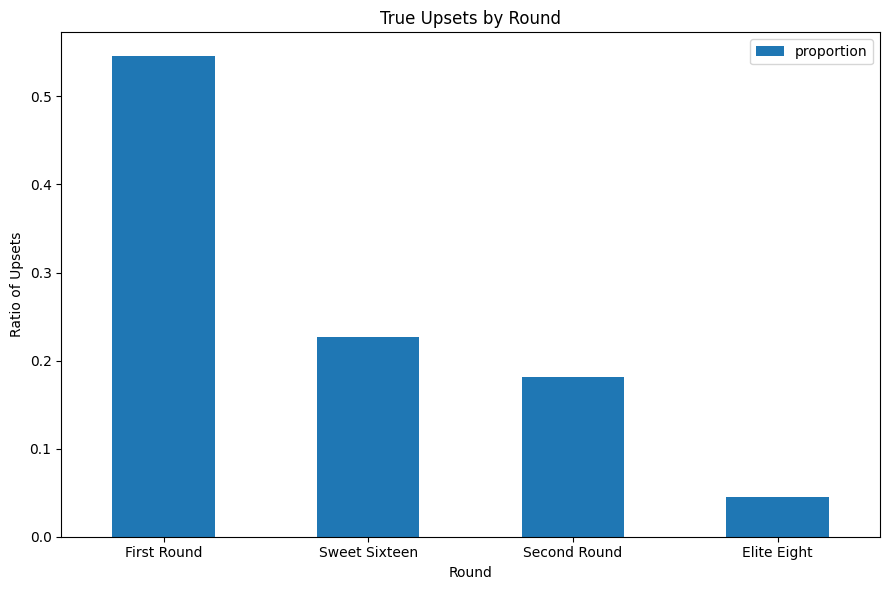

In [38]:
# Group upset seed pairs by round and count them
true_upset_rounds_freq = true_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
true_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='True Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(true_upset_pairs)}")

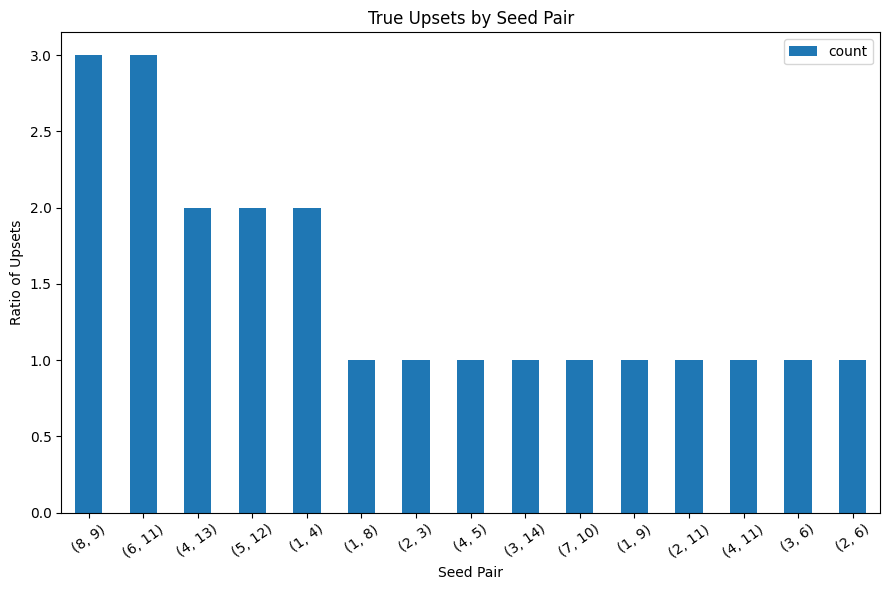

In [39]:
# Group upsets by seed pairing and count them
true_upset_pairs_freq = true_upset_pairs['Pairs'].value_counts()

# Plot findings
true_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='True Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

### Compare Predicitons to True Outcomes

In [40]:
# Display correct predictions by round
correct_preds_df = pd.DataFrame(columns=['# Correct Preds', '# Possible Preds'])

for _round in bracket_trues['Round'].unique():
    # Extract round data from predictions & trues
    trues_round = bracket_trues[bracket_trues['Round'] == _round]
    preds_round = bracket_preds[bracket_preds['Round'] == _round]
    
    # Intersection of predictions & trues indicates the model's correct picks
    correct_preds = set(trues_round['Winner']).intersection(set(preds_round['Winner']))
    
    # Input data into Dataframe
    correct_preds_df.loc[_round] = [len(correct_preds), len(preds_round)]
    
correct_preds_df.loc['Tournament Total'] = [correct_preds_df['# Correct Preds'].sum(), correct_preds_df['# Possible Preds'].sum()]
    
correct_preds_df

,# Correct Preds,# Possible Preds
Play-In,3,4
First Round,25,32
Second Round,13,16
Sweet Sixteen,5,8
Elite Eight,2,4
Final Four,1,2
National Championship,1,1
Tournament Total,50,67


In [41]:
# Calculate and output the model's accuracy
tourney_totals = correct_preds_df.loc['Tournament Total']
print(f"Accuracy: {np.round(tourney_totals['# Correct Preds'] / tourney_totals['# Possible Preds'], 3)}")

Accuracy: 0.746
